In [1]:
import os, random, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
import cv2, torch, numpy as np
from rembg import remove, new_session
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import gc

# ---------- one-time loaders ----------
MODEL_NAME = "isnet-general-use"
_SESSION = new_session(MODEL_NAME)        # ISNet via rembg

_SAM_CKPT   = "../models/sam_vit_h_4b8939.pth"      # put the weight file here
_SAM_TYPE   = "vit_h"
_DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

_sam  = sam_model_registry[_SAM_TYPE](checkpoint=_SAM_CKPT).to(_DEVICE)
_MASK_GEN = SamAutomaticMaskGenerator(_sam)     # default hyper-params OK


def _criterion(mask_sam: np.ndarray,
               mask_isnet: np.ndarray,
               dataset: str) -> bool:
    """Return True if mask_sam should be kept."""
    ds = dataset.lower()
    if ds == "atrw":
        # IoU ≥ 0.30
        inter = np.logical_and(mask_sam, mask_isnet).sum()
        union = np.logical_or(mask_sam, mask_isnet).sum()
        return inter / union >= 0.30
    else:
        inter = np.logical_and(mask_sam, mask_isnet).sum()
        union = np.logical_or(mask_sam, mask_isnet).sum()
        return inter / union >= 0.35
    return True


# ---------- public API ----------
def sam_isnet_mask(image_bgr: np.ndarray, dataset: str) -> np.ndarray:
    # 1) ISNet (coarse / complete)
    _, buf = cv2.imencode(".png", image_bgr)
    mask_bytes = remove(buf.tobytes(),
                        session=_SESSION,
                        only_mask=True,
                        post_process_mask=True)
    mask_isnet = cv2.imdecode(                     
        np.frombuffer(mask_bytes, np.uint8),
        cv2.IMREAD_UNCHANGED)
    if mask_isnet.ndim == 3:                       
        mask_isnet = mask_isnet[..., 0]
    mask_isnet = mask_isnet > 0 

    # 2) SAM  (sharp instances)
    #anns = _MASK_GEN.generate(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    with torch.no_grad():        # don’t build autograd graph
        anns = _MASK_GEN.generate(
            cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    sam_masks = [a["segmentation"] for a in anns]

    kept = [m for m in sam_masks if _criterion(m, mask_isnet, dataset)]
    if not kept:                           # fall-back
        return mask_isnet

    final = mask_isnet.copy()
    for m in kept:
        np.logical_or(final, m, out=final)
        
    del anns, sam_masks
    torch.cuda.empty_cache()     # release cached blocks
    gc.collect()                 # help Python recycle CPU objs
    return final


def apply_mask(image_bgr: np.ndarray, mask_fg: np.ndarray) -> np.ndarray:
    """White background; keeps 3-channels in uint8."""
    out = image_bgr.copy()
    out[~mask_fg] = 255
    return out

In [3]:
CSV_PATH    = "../data/wildlifedatasets/wildlifereid-10k/versions/7/metadata.csv"                         
DATA_ROOT   = "../data/wildlifedatasets/wildlifereid-10k/versions/7/"                                      
WHAT_DATASET = "Cows2021"
N_SAMPLES   = 8                                         # how many pictures to visualise

df = pd.read_csv(CSV_PATH)
df_ds = df[df["dataset"] == WHAT_DATASET]

# reproducible random pick
random.seed(42)
sample_rows = df_ds.sample(n=N_SAMPLES, random_state=42).reset_index(drop=True)
sample_rows


/tmp/ipykernel_3681743/2582498365.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


,identity,path,date,orientation,species,split,dataset,cluster_id
0,Cows2021_66,images/Cows2021/4vnrca7qw1642qlwxjadp87h7/Sub-...,2020-02-13,NaN,cow,train,Cows2021,Cows2021_66_3698
1,Cows2021_136,images/Cows2021/4vnrca7qw1642qlwxjadp87h7/Sub-...,2020-02-11,NaN,cow,train,Cows2021,Cows2021_136_1029
2,Cows2021_136,images/Cows2021/4vnrca7qw1642qlwxjadp87h7/Sub-...,2020-02-19,NaN,cow,train,Cows2021,Cows2021_136_1039
3,Cows2021_44,images/Cows2021/4vnrca7qw1642qlwxjadp87h7/Sub-...,2020-02-11,NaN,cow,train,Cows2021,Cows2021_44_3013
4,Cows2021_25,images/Cows2021/4vnrca7qw1642qlwxjadp87h7/Sub-...,2020-03-05,NaN,cow,test,Cows2021,Cows2021_25_2491
5,Cows2021_149,images/Cows2021/4vnrca7qw1642qlwxjadp87h7/Sub-...,2020-02-22,NaN,cow,test,Cows2021,Cows2021_149_1465
6,Cows2021_9,images/Cows2021/4vnrca7qw1642qlwxjadp87h7/Sub-...,2020-02-19,NaN,cow,train,Cows2021,Cows2021_9_4324
7,Cows2021_93,images/Cows2021/4vnrca7qw1642qlwxjadp87h7/Sub-...,2020-02-28,NaN,cow,test,Cows2021,Cows2021_93_4441


In [ ]:
processed = []        # will hold (orig, masked) image pairs for plotting

for _, row in tqdm(sample_rows.iterrows(), total=len(sample_rows)):
    img_path = os.path.join(DATA_ROOT, row["path"])     # e.g. images/AAUZebraFish/…
    img = cv2.imread(img_path)                          # BGR uint8

    # --- paper’s hybrid mask ---
    mask = sam_isnet_mask(img, row["dataset"])          # dataset-aware thresholds
    img_masked = apply_mask(img, mask)                  # white bg

    # convert to RGB for matplotlib
    processed.append((cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
                      cv2.cvtColor(img_masked, cv2.COLOR_BGR2RGB)))
    
    torch.cuda.empty_cache()
    gc.collect()  

In [ ]:
cols = 2
rows = len(processed)
fig, axes = plt.subplots(rows, cols, figsize=(8, 4*rows))

for r, (orig, masked) in enumerate(processed):
    axes[r, 0].imshow(orig);    axes[r, 0].set_title("Original"); axes[r, 0].axis("off")
    axes[r, 1].imshow(masked);  axes[r, 1].set_title("Masked");   axes[r, 1].axis("off")

plt.tight_layout()
plt.show()


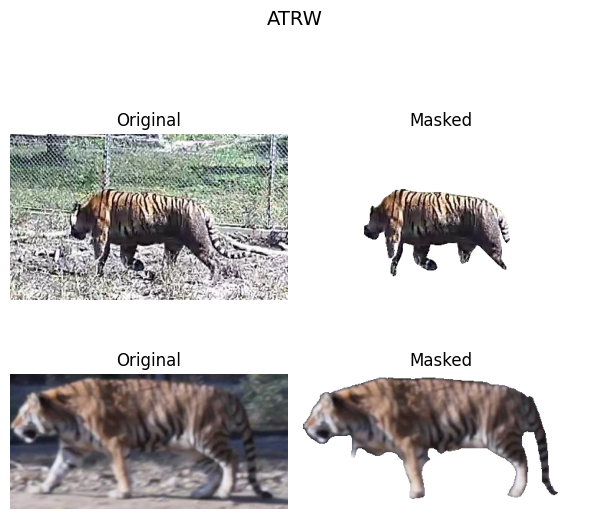

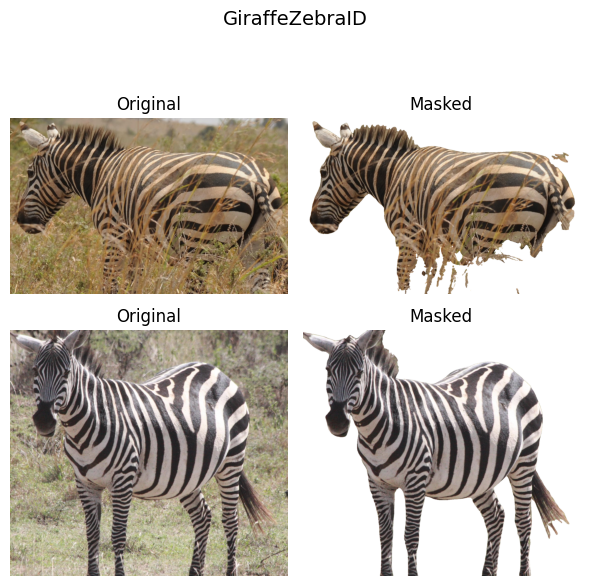

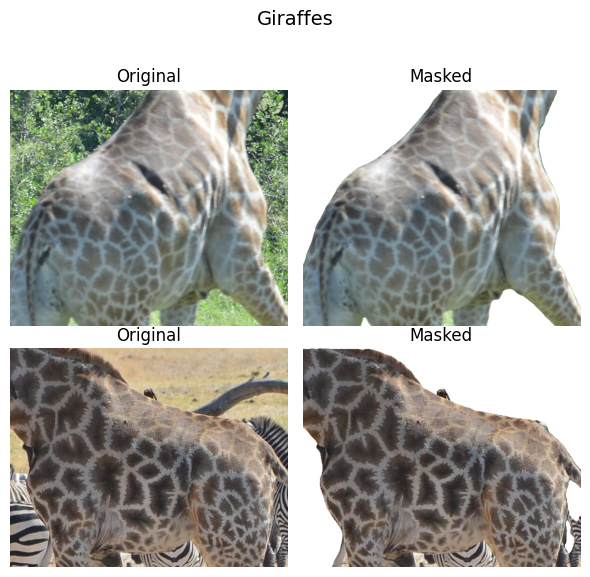

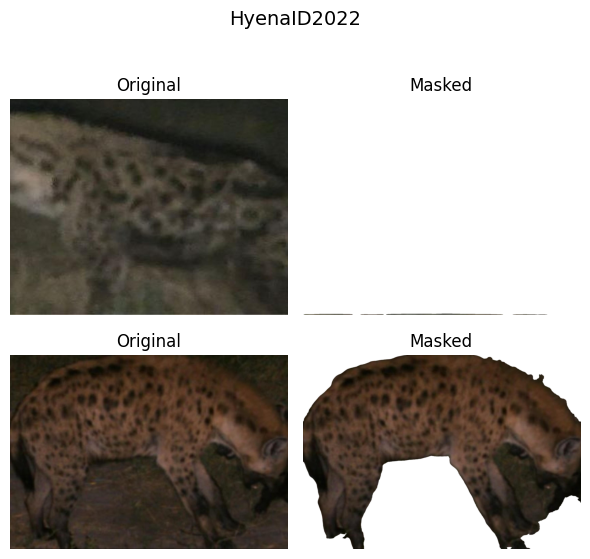

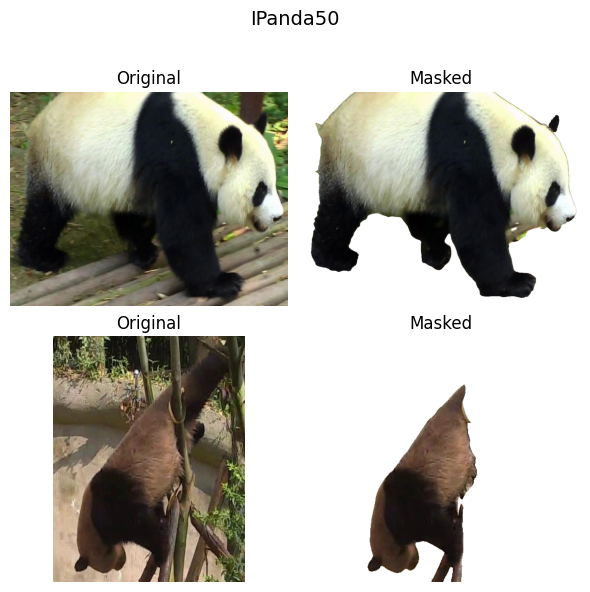

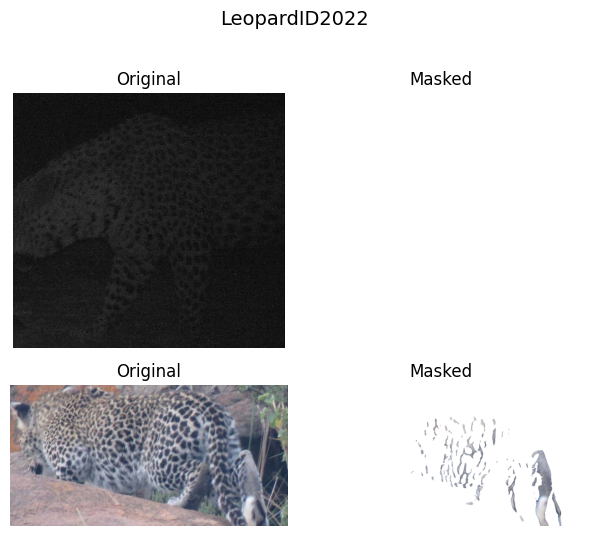

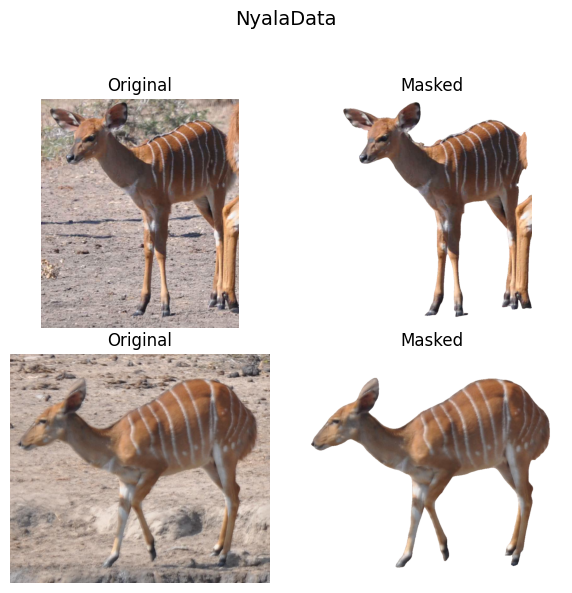

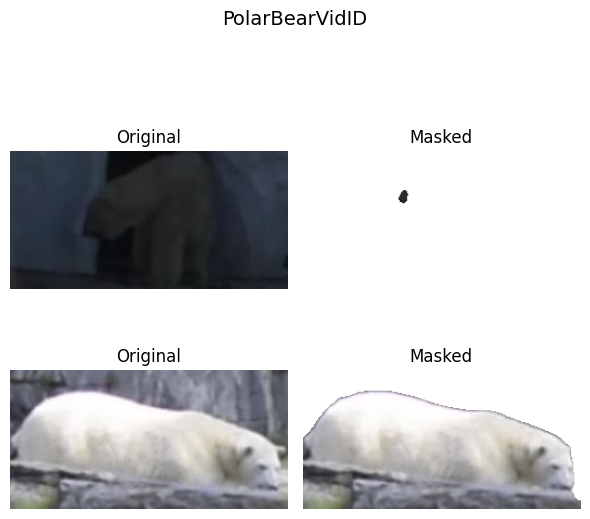

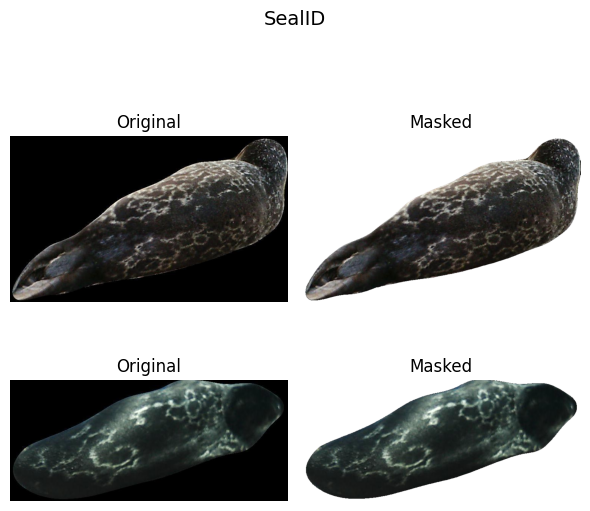

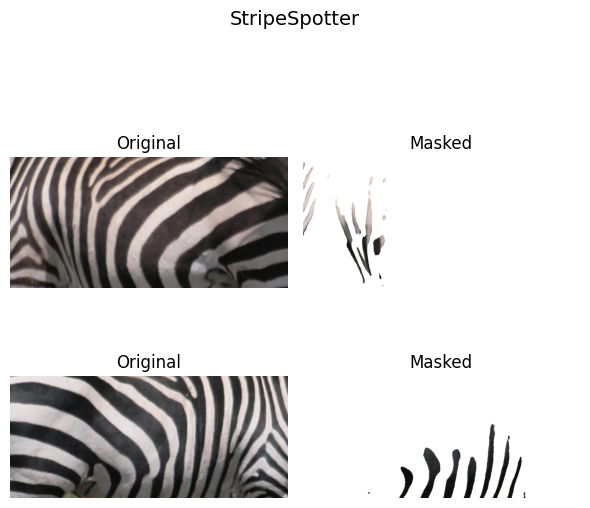

OutOfMemoryError: CUDA out of memory. Tried to allocate 5.22 GiB. GPU 0 has a total capacity of 15.58 GiB of which 2.68 GiB is free. Including non-PyTorch memory, this process has 12.88 GiB memory in use. Of the allocated memory 11.25 GiB is allocated by PyTorch, and 83.76 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

: 

In [ ]:
import gc, torch, random, matplotlib.pyplot as plt
random.seed(0)                 # reproducible across runs

DATASETS = [
    "ATRW", "GiraffeZebraID", "Giraffes", "HyenaID2022",
    "IPanda50", "LeopardID2022", "NyalaData", "PolarBearVidID", "SealID",
    "StripeSpotter", "SeaStarReID2023", "SeaTurtleID", "WhaleSharkID",
    "BelugaID", "NDD20",
]
N_PER_DS = 2                   # how many images per dataset
FIG_W, FIG_H = 6, 6           # inches per dataset grid

for ds in DATASETS:
    sub = df[df["dataset"] == ds]
    if len(sub) < N_PER_DS:
        print(f"⚠  {ds}: only {len(sub)} images, skipping"); continue

    rows = sub.sample(N_PER_DS, random_state=random.randint(0, 10**6))

    # --- run segmentation & collect pairs ---
    pairs = []
    for _, row in rows.iterrows():
        img_path = os.path.join(DATA_ROOT, row["path"])
        img = cv2.imread(img_path)                       # BGR → SAM expects RGB
        mask = sam_isnet_mask(img, ds)                   # dataset-aware rule
        masked = apply_mask(img, mask)

        # convert for matplotlib
        pairs.append((
            cv2.cvtColor(img,     cv2.COLOR_BGR2RGB),
            cv2.cvtColor(masked,  cv2.COLOR_BGR2RGB),
        ))

        # release temp tensors
        torch.cuda.empty_cache();  gc.collect()

    # --- visualise (2 × 2) ---
    fig, axes = plt.subplots(2, 2, figsize=(FIG_W, FIG_H))
    fig.suptitle(ds, fontsize=14)
    for i, (orig, msk) in enumerate(pairs):
        r = i // 1                       # row index 0 or 1
        axes[r, 0].imshow(orig); axes[r, 0].set_title("Original")
        axes[r, 1].imshow(msk);  axes[r, 1].set_title("Masked")
        axes[r, 0].axis("off"); axes[r, 1].axis("off")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()